# 03_attribution.ipynb

> Compute SHAP and LIME attributions for the sampled cases
> Samples the analysis cases, computes attributions under every model x XAI
> combination, and exports the structured evidence blocks that will be handed
> to the LLMs in 07_generation.

[credit] test set (9723, 22), models ['XGBoost', 'LightGBM', 'RandomForest']
[churn] test set (2107, 30), models ['XGBoost', 'LightGBM', 'RandomForest']
[credit] main 300, bridge 100, deep 60
  strata: {'low': 113, 'high': 112, 'boundary': 75}
[churn] main 300, bridge 100, deep 60
  strata: {'low': 113, 'high': 112, 'boundary': 75}
Saved: case_registry.parquet (920 rows)
[skip] attr_credit_XGBoost_SHAP.parquet already exists
[run] credit / XGBoost / LIME (300 cases)
      done in 22.1s -> attr_credit_XGBoost_LIME.parquet
[skip] attr_credit_LightGBM_SHAP.parquet already exists
[run] credit / LightGBM / LIME (300 cases)
      done in 53.4s -> attr_credit_LightGBM_LIME.parquet
[skip] attr_credit_RandomForest_SHAP.parquet already exists
[run] credit / RandomForest / LIME (300 cases)
      done in 136.7s -> attr_credit_RandomForest_LIME.parquet
[skip] attr_churn_XGBoost_SHAP.parquet already exists
[run] churn / XGBoost / LIME (300 cases)
      done in 16.3s -> attr_churn_XGBoost_LIME.parque

,Domain,Model,XAI,N cases,Seconds
0,credit,XGBoost,LIME,300,22.1
1,credit,LightGBM,LIME,300,53.4
2,credit,RandomForest,LIME,300,136.7
3,churn,XGBoost,LIME,300,16.3
4,churn,LightGBM,LIME,300,35.7
5,churn,RandomForest,LIME,300,86.5


Attribution rows: 93,600
  domain     model   xai  case_id  base_value        feature  contribution
0  churn  LightGBM  LIME        1    0.264705  SeniorCitizen     -0.033880
1  churn  LightGBM  LIME        6    0.264705  SeniorCitizen     -0.033891
2  churn  LightGBM  LIME       11    0.264705  SeniorCitizen      0.032529
3  churn  LightGBM  LIME       14    0.264705  SeniorCitizen     -0.029226
4  churn  LightGBM  LIME       15    0.264705  SeniorCitizen     -0.027454
Top-5 rows: 18,000
Saved: attributions_topk.parquet
Updated: attributions_topk.parquet (with normalised contributions)
Evidence blocks: 3,600
Saved: evidence_blocks.json

Example block:
{
  "domain": "churn",
  "model": "LightGBM",
  "xai": "LIME",
  "case_id": 1,
  "predicted_probability": 0.0187,
  "base_value": 0.2647,
  "drivers": [
    {
      "feature": "Contract_Two_year",
      "contribution": 0.165101,
      "contribution_norm": 0.3559,
      "direction": "increases",
      "rank": 1
    },
    {
      "feature

,domain,model,n_cases,feature_jaccard_mean,feature_jaccard_sd,direction_agreement_mean,rank_tau_mean
0,churn,LightGBM,300,0.6436,0.1635,0.9992,0.2934
1,churn,RandomForest,300,0.6209,0.1900,1.0000,0.4101
2,churn,XGBoost,300,0.4356,0.1281,1.0000,-0.0399
3,credit,LightGBM,300,0.1695,0.0945,0.9490,-0.2500
4,credit,RandomForest,300,0.2711,0.1275,0.9685,0.3766
5,credit,XGBoost,300,0.1453,0.0913,0.9241,-0.1667


Saved: tab07_cross_model_attribution_agreement.csv


,domain,xai,pair,feature_jaccard_mean,direction_agreement_mean
0,churn,LIME,LightGBM vs RandomForest,0.6745,1.0000
1,churn,LIME,XGBoost vs LightGBM,0.7208,1.0000
2,churn,LIME,XGBoost vs RandomForest,0.5611,1.0000
3,churn,SHAP,LightGBM vs RandomForest,0.6375,1.0000
4,churn,SHAP,XGBoost vs LightGBM,0.7451,1.0000
5,churn,SHAP,XGBoost vs RandomForest,0.7177,1.0000
6,credit,LIME,LightGBM vs RandomForest,0.5051,1.0000
7,credit,LIME,XGBoost vs LightGBM,0.8056,1.0000
8,credit,LIME,XGBoost vs RandomForest,0.5264,1.0000
9,credit,SHAP,LightGBM vs RandomForest,0.6031,0.9924


Saved: fig07_shap_lime_overlap.png / fig07_shap_lime_overlap.pdf


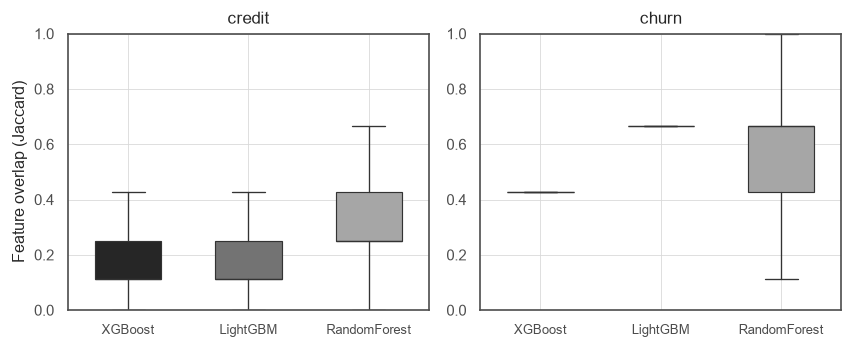

Saved: fig08_direction_agreement.png / fig08_direction_agreement.pdf


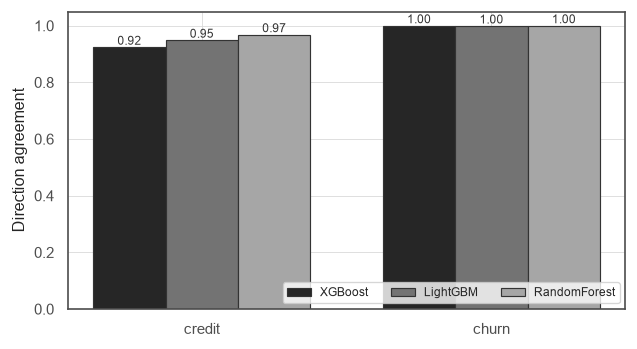

Saved: fig09_top_driver_frequency.png / fig09_top_driver_frequency.pdf


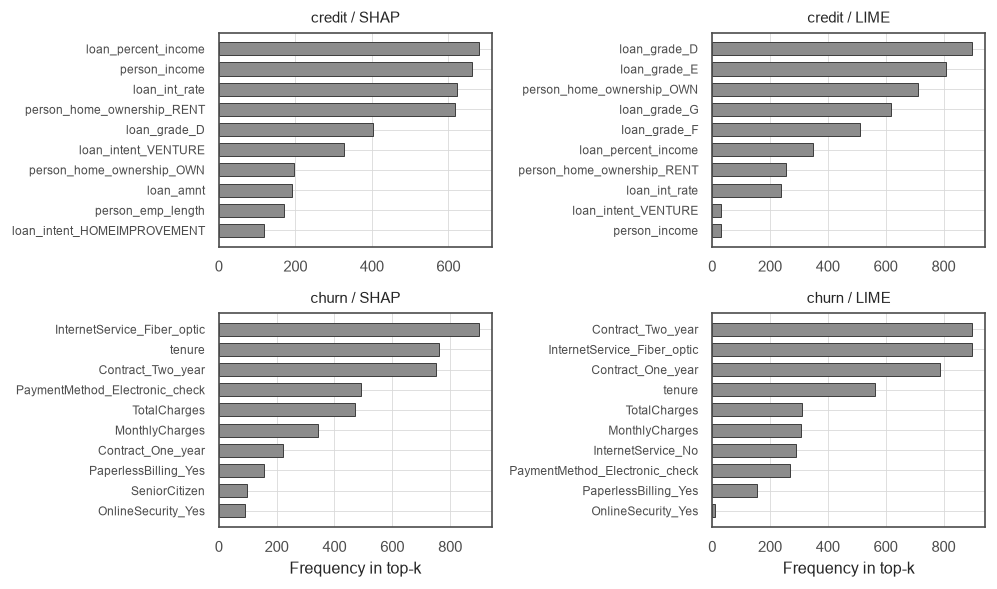

Saved: tab08_attribution_summary.csv


,Domain,Model,XAI,N cases,N drivers,Unique features,Pct increasing
0,credit,XGBoost,SHAP,300,1500,22,50.1
1,credit,XGBoost,LIME,300,1500,11,38.7
2,credit,LightGBM,SHAP,300,1500,22,63.3
3,credit,LightGBM,LIME,300,1500,10,37.2
4,credit,RandomForest,SHAP,300,1500,20,53.1
5,credit,RandomForest,LIME,300,1500,12,41.7
6,churn,XGBoost,SHAP,300,1500,16,59.3
7,churn,XGBoost,LIME,300,1500,9,80.3
8,churn,LightGBM,SHAP,300,1500,14,69.9
9,churn,LightGBM,LIME,300,1500,11,76.7


Saved: logs/03_run_20260911.json
Attribution artefacts:
  attr_churn_LightGBM_LIME.parquet                 104.9 KB
  attr_churn_LightGBM_SHAP.parquet                  94.2 KB
  attr_churn_RandomForest_LIME.parquet             105.0 KB
  attr_churn_RandomForest_SHAP.parquet             105.0 KB
  attr_churn_XGBoost_LIME.parquet                  104.9 KB
  attr_churn_XGBoost_SHAP.parquet                   58.7 KB
  attr_credit_LightGBM_LIME.parquet                 77.7 KB
  attr_credit_LightGBM_SHAP.parquet                 77.7 KB
  attr_credit_RandomForest_LIME.parquet             77.7 KB
  attr_credit_RandomForest_SHAP.parquet             77.7 KB
  attr_credit_XGBoost_LIME.parquet                  77.7 KB
  attr_credit_XGBoost_SHAP.parquet                  51.2 KB
  attributions_topk.parquet                        540.1 KB
  evidence_blocks.json                            3460.4 KB
  case_registry.parquet                              7.1 KB

Outputs:
  results\figures\fig07_shap_lime_

In [2]:
# ============================================================================
# 03_attribution.ipynb
# Compute SHAP and LIME attributions for the sampled cases
# Samples the analysis cases, computes attributions under every model x XAI
# combination, and exports the structured evidence blocks that will be handed
# to the LLMs in 07_generation.
# ============================================================================


# [Cell 1] Imports and global configuration
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import shap
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import kendalltau

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
LOG_DIR = ROOT / "logs"

for d in [DATA_DIR, FIG_DIR, TAB_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# [Cell 2] Plotting style: grayscale, publication settings
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})

LINE_STYLES = {"XGBoost": "-", "LightGBM": "--", "RandomForest": ":"}
GRAY_LEVELS = {"XGBoost": "0.15", "LightGBM": "0.45", "RandomForest": "0.65"}


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Study configuration
DOMAINS = ["credit", "churn"]
MODEL_NAMES = ["XGBoost", "LightGBM", "RandomForest"]
XAI_METHODS = ["SHAP", "LIME"]

# Case sampling
N_CASES_MAIN = 300        # Blocks A, A', B
N_CASES_BRIDGE = 100      # Block C  (subset of the main sample)
N_CASES_DEEP = 60         # Blocks D, D-0 (subset of the bridge sample)

# Number of top drivers handed to the LLM.
# Fixed across every condition so that variability cannot be attributed to
# differences in how much evidence the model receives.
TOP_K = 5

# LIME settings
LIME_N_SAMPLES = 5000     # perturbation samples per instance
LIME_SEED = SEED


# [Cell 4] Load data, models and registry
def load_split(domain):
    """Load the fixed train/test split produced in 01_data_prep."""
    out = {}
    for key in ["X_train", "X_test", "y_train", "y_test"]:
        df = pd.read_parquet(DATA_DIR / f"{domain}_{key}.parquet")
        out[key] = df.iloc[:, 0] if key.startswith("y") else df
    return out


data = {d: load_split(d) for d in DOMAINS}

models = {
    d: {m: joblib.load(DATA_DIR / f"model_{d}_{m}.joblib") for m in MODEL_NAMES}
    for d in DOMAINS
}

with open(DATA_DIR / "feature_registry.json", encoding="utf-8") as f:
    feature_registry = json.load(f)

pred_all = pd.read_parquet(DATA_DIR / "test_predictions.parquet")

for d in DOMAINS:
    print(f"[{d}] test set {data[d]['X_test'].shape}, models {list(models[d])}")


# [Cell 5] Case sampling
# Cases are stratified by predicted probability so that the sample spans the
# full risk range rather than concentrating in one region. A dedicated boundary
# stratum is included because near-threshold cases are where explanation
# instability carries the greatest practical consequence.
REFERENCE_MODEL = "XGBoost"     # used only to define the strata
BOUNDARY_WIDTH = 0.05           # +/- band around the decision threshold
THRESHOLD = 0.5


def sample_cases(domain, n_cases, seed=SEED):
    """Stratified sample of test-set cases across the predicted risk range."""
    sub = pred_all[pred_all["domain"] == domain].copy()
    p = sub[f"proba_{REFERENCE_MODEL}"]

    # Four strata: low, boundary, mid, high
    boundary = p.between(THRESHOLD - BOUNDARY_WIDTH, THRESHOLD + BOUNDARY_WIDTH)
    sub["stratum"] = np.select(
        [
            boundary,
            p < THRESHOLD - BOUNDARY_WIDTH,
            p > THRESHOLD + BOUNDARY_WIDTH,
        ],
        ["boundary", "low", "high"],
        default="mid",
    )

    # Boundary stratum is deliberately over-represented (one quarter of the sample)
    quota = {
        "boundary": int(n_cases * 0.25),
        "low": int(n_cases * 0.375),
        "high": int(n_cases * 0.375),
    }
    quota["low"] += n_cases - sum(quota.values())   # absorb rounding

    rng = np.random.default_rng(seed)
    picked = []
    for stratum, k in quota.items():
        pool = sub[sub["stratum"] == stratum]
        if len(pool) == 0:
            print(f"  WARNING [{domain}] stratum '{stratum}' is empty")
            continue
        take = min(k, len(pool))
        if take < k:
            print(f"  WARNING [{domain}] stratum '{stratum}': "
                  f"requested {k}, available {len(pool)}")
        picked.append(pool.sample(n=take, random_state=rng.integers(1e6)))

    out = pd.concat(picked).sort_values("case_id").reset_index(drop=True)
    return out


case_sets = {}
for domain in DOMAINS:
    main = sample_cases(domain, N_CASES_MAIN)
    # Nested subsets keep the blocks comparable to one another
    bridge = main.sample(n=N_CASES_BRIDGE, random_state=SEED).sort_values("case_id")
    deep = bridge.sample(n=N_CASES_DEEP, random_state=SEED).sort_values("case_id")

    case_sets[domain] = {
        "main": main.reset_index(drop=True),
        "bridge": bridge.reset_index(drop=True),
        "deep": deep.reset_index(drop=True),
    }
    print(f"[{domain}] main {len(main)}, bridge {len(bridge)}, deep {len(deep)}")
    print(f"  strata: {main['stratum'].value_counts().to_dict()}")


# [Cell 6] Persist the case registry
case_rows = []
for domain in DOMAINS:
    for level in ["main", "bridge", "deep"]:
        df = case_sets[domain][level][["case_id", "y_true", "stratum"]].copy()
        df["domain"] = domain
        df["case_set"] = level
        case_rows.append(df)

case_registry = pd.concat(case_rows, ignore_index=True)
case_registry.to_parquet(DATA_DIR / "case_registry.parquet", index=False)
print(f"Saved: case_registry.parquet ({len(case_registry):,} rows)")


# [Cell 7] SHAP computation
def compute_shap(model, model_name, X_background, X_cases):
    """Return a SHAP value matrix for the positive class."""
    if model_name in ("XGBoost", "LightGBM", "RandomForest"):
        explainer = shap.TreeExplainer(model)
        values = explainer.shap_values(X_cases)
        # Some versions return a list per class; keep the positive class
        if isinstance(values, list):
            values = values[1]
        # Newer versions may return a 3-D array (n, features, classes)
        if values.ndim == 3:
            values = values[:, :, 1]
        base = float(model.predict_proba(X_background)[:, 1].mean())
    else:
        raise ValueError(f"No SHAP strategy for {model_name}")

    return np.asarray(values), float(base)


# [Cell 8] LIME computation
def build_lime_explainer(X_train, feature_names):
    """Create a tabular LIME explainer fitted on the training distribution."""
    # One-hot columns are binary and must not be discretised. Leaving them to
    # the continuous discretiser concentrates weight on the genuinely numeric
    # columns, which is why LIME was selecting from a narrow subset.
    categorical_idx = [
        i for i, c in enumerate(feature_names)
        if set(X_train[c].dropna().unique()) <= {0, 1}
    ]
    return LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=feature_names,
        class_names=["negative", "positive"],
        mode="classification",
        discretize_continuous=True,
        categorical_features=categorical_idx,
        random_state=LIME_SEED,
    )


def compute_lime_row(explainer, model, x_row, n_features):
    """Return a dense LIME attribution vector for one instance."""
    exp = explainer.explain_instance(
        data_row=x_row.values,
        predict_fn=model.predict_proba,
        num_features=n_features,
        num_samples=LIME_N_SAMPLES,
        labels=(1,),
    )
    vec = np.zeros(n_features)
    for idx, weight in exp.as_map()[1]:
        vec[idx] = weight
    return vec


# [Cell 9] Run attribution for all domain x model x XAI combinations
# Results are cached per combination so that an interrupted run can resume.
attribution_records = []
timing_records = []

for domain in DOMAINS:
    X_train = data[domain]["X_train"]
    X_test = data[domain]["X_test"]
    feature_names = X_train.columns.tolist()
    n_features = len(feature_names)

    cases = case_sets[domain]["main"]
    case_ids = cases["case_id"].values
    X_cases = X_test.iloc[case_ids].reset_index(drop=True)

    lime_explainer = build_lime_explainer(X_train, feature_names)

    for model_name in MODEL_NAMES:
        model = models[domain][model_name]

        for xai in XAI_METHODS:
            cache = DATA_DIR / f"attr_{domain}_{model_name}_{xai}.parquet"
            if cache.exists():
                print(f"[skip] {cache.name} already exists")
                continue

            print(f"[run] {domain} / {model_name} / {xai} "
                  f"({len(case_ids)} cases)")
            t0 = time.time()

            if xai == "SHAP":
                values, base = compute_shap(model, model_name, X_train, X_cases)
            else:
                values = np.vstack([
                    compute_lime_row(lime_explainer, model, X_cases.iloc[i], n_features)
                    for i in range(len(X_cases))
                ])
                base = float(model.predict_proba(X_train)[:, 1].mean())

            elapsed = time.time() - t0

            frame = pd.DataFrame(values, columns=feature_names)
            frame.insert(0, "case_id", case_ids)
            frame.insert(0, "xai", xai)
            frame.insert(0, "model", model_name)
            frame.insert(0, "domain", domain)
            frame["base_value"] = base
            frame.to_parquet(cache, index=False)

            timing_records.append({
                "Domain": domain, "Model": model_name, "XAI": xai,
                "N cases": len(case_ids), "Seconds": round(elapsed, 1),
            })
            print(f"      done in {elapsed:.1f}s -> {cache.name}")

timing = pd.DataFrame(timing_records)
if len(timing):
    save_table(timing, "tab05_attribution_runtime")
display(timing)


# [Cell 10] Assemble attributions into long format
def load_attributions():
    """Read all cached attribution matrices and reshape to long format."""
    frames = []
    for path in sorted(DATA_DIR.glob("attr_*.parquet")):
        wide = pd.read_parquet(path)
        meta_cols = ["domain", "model", "xai", "case_id", "base_value"]
        feat_cols = [c for c in wide.columns if c not in meta_cols]
        long = wide.melt(
            id_vars=meta_cols,
            value_vars=feat_cols,
            var_name="feature",
            value_name="contribution",
        )
        frames.append(long)
    return pd.concat(frames, ignore_index=True)


attr_long = load_attributions()
print(f"Attribution rows: {len(attr_long):,}")
print(attr_long.head())


# [Cell 11] Rank and select the top-k drivers
# Direction is derived from the sign of the contribution. The label depends on
# the domain's positive class, which is what the narrative must convey.
def add_rank_and_direction(df):
    """Rank features by absolute contribution within each case and label sign."""
    df = df.copy()
    df["abs_contribution"] = df["contribution"].abs()
    df["rank"] = (
        df.groupby(["domain", "model", "xai", "case_id"])["abs_contribution"]
          .rank(ascending=False, method="first")
          .astype(int)
    )
    df["direction"] = np.where(df["contribution"] >= 0, "increases", "decreases")
    return df


attr_long = add_rank_and_direction(attr_long)
top_k = attr_long[attr_long["rank"] <= TOP_K].sort_values(
    ["domain", "model", "xai", "case_id", "rank"]
).reset_index(drop=True)

print(f"Top-{TOP_K} rows: {len(top_k):,}")
top_k.to_parquet(DATA_DIR / "attributions_topk.parquet", index=False)
print("Saved: attributions_topk.parquet")


# [Cell 12] Normalise contribution magnitudes
# SHAP and LIME operate on different scales. Values are normalised within each
# case so that the LLM receives comparable magnitudes regardless of the XAI
# method, isolating the method's effect on which features are selected rather
# than on how large the numbers look.
def normalise_within_case(df):
    """Scale contributions so that absolute values sum to one within a case."""
    df = df.copy()
    denom = (
        df.groupby(["domain", "model", "xai", "case_id"])["abs_contribution"]
          .transform("sum")
    )
    df["contribution_norm"] = df["contribution"] / denom.replace(0, np.nan)
    df["contribution_norm"] = df["contribution_norm"].fillna(0.0)
    return df


top_k = normalise_within_case(top_k)
top_k.to_parquet(DATA_DIR / "attributions_topk.parquet", index=False)
print("Updated: attributions_topk.parquet (with normalised contributions)")


# [Cell 13] Build structured evidence blocks for the LLM
# Each block is the exact payload handed to the model. Storing it verbatim is
# what makes the fidelity measurement possible: the reference for "what the LLM
# was told" is this object, not the raw SHAP matrix.
def build_evidence_blocks(top_k_df, pred_df):
    """Create one evidence record per (domain, model, xai, case)."""
    blocks = []
    grouped = top_k_df.groupby(["domain", "model", "xai", "case_id"], sort=False)

    for (domain, model_name, xai, case_id), g in grouped:
        g = g.sort_values("rank")
        pred_row = pred_df[
            (pred_df["domain"] == domain) & (pred_df["case_id"] == case_id)
        ].iloc[0]

        blocks.append({
            "domain": domain,
            "model": model_name,
            "xai": xai,
            "case_id": int(case_id),
            "predicted_probability": round(float(pred_row[f"proba_{model_name}"]), 4),
            "base_value": round(float(g["base_value"].iloc[0]), 4),
            "drivers": [
                {
                    "feature": row["feature"],
                    "contribution": round(float(row["contribution"]), 6),
                    "contribution_norm": round(float(row["contribution_norm"]), 4),
                    "direction": row["direction"],
                    "rank": int(row["rank"]),
                }
                for _, row in g.iterrows()
            ],
        })
    return blocks


evidence_blocks = build_evidence_blocks(top_k, pred_all)
print(f"Evidence blocks: {len(evidence_blocks):,}")

with open(DATA_DIR / "evidence_blocks.json", "w", encoding="utf-8") as f:
    json.dump(evidence_blocks, f, ensure_ascii=False, indent=1)
print("Saved: evidence_blocks.json")

print("\nExample block:")
print(json.dumps(evidence_blocks[0], ensure_ascii=False, indent=2))


# [Cell 14] Attribution agreement between SHAP and LIME
# This is a prerequisite for interpreting Block A. If SHAP and LIME already
# disagree on the drivers, part of the downstream narrative variability
# originates before the LLM stage.
def attribution_agreement(top_k_df):
    """Compare SHAP and LIME driver sets within each (domain, model, case)."""
    rows = []
    keys = ["domain", "model", "case_id"]

    shap_df = top_k_df[top_k_df["xai"] == "SHAP"]
    lime_df = top_k_df[top_k_df["xai"] == "LIME"]

    merged = shap_df.groupby(keys).apply(
        lambda g: g.sort_values("rank")[["feature", "direction"]].values.tolist()
    ).rename("shap").reset_index()
    merged_l = lime_df.groupby(keys).apply(
        lambda g: g.sort_values("rank")[["feature", "direction"]].values.tolist()
    ).rename("lime").reset_index()
    merged = merged.merge(merged_l, on=keys, how="inner")

    for _, r in merged.iterrows():
        s_feats = [x[0] for x in r["shap"]]
        l_feats = [x[0] for x in r["lime"]]
        s_dir = dict(r["shap"])
        l_dir = dict(r["lime"])

        common = set(s_feats) & set(l_feats)
        union = set(s_feats) | set(l_feats)
        jaccard = len(common) / len(union) if union else np.nan

        dir_match = (
            np.mean([s_dir[f] == l_dir[f] for f in common]) if common else np.nan
        )

        if len(common) >= 3:
            s_rank = {f: i for i, f in enumerate(s_feats)}
            l_rank = {f: i for i, f in enumerate(l_feats)}
            ordered = sorted(common)
            tau = kendalltau(
                [s_rank[f] for f in ordered],
                [l_rank[f] for f in ordered],
            ).correlation
        else:
            tau = np.nan

        rows.append({
            "domain": r["domain"], "model": r["model"], "case_id": r["case_id"],
            "feature_jaccard": jaccard,
            "direction_agreement": dir_match,
            "rank_tau": tau,
        })

    return pd.DataFrame(rows)


agreement = attribution_agreement(top_k)
agreement.to_parquet(DATA_DIR / "attribution_agreement.parquet", index=False)

agree_summary = (
    agreement.groupby(["domain", "model"])
    .agg(
        n_cases=("case_id", "count"),
        feature_jaccard_mean=("feature_jaccard", "mean"),
        feature_jaccard_sd=("feature_jaccard", "std"),
        direction_agreement_mean=("direction_agreement", "mean"),
        rank_tau_mean=("rank_tau", "mean"),
    )
    .round(4)
    .reset_index()
)

save_table(agree_summary, "tab06_shap_lime_agreement")
display(agree_summary)


# [Cell 15] Cross-model agreement on attributions
# Complements the SHAP/LIME comparison: how much do the drivers change when the
# prediction model changes, holding the XAI method fixed?
def cross_model_agreement(top_k_df, xai="SHAP"):
    """Compare driver sets across models within each (domain, case)."""
    sub = top_k_df[top_k_df["xai"] == xai]
    rows = []

    for domain in sub["domain"].unique():
        d = sub[sub["domain"] == domain]
        by_case = d.groupby(["case_id", "model"]).apply(
            lambda g: g.sort_values("rank")[["feature", "direction"]].values.tolist()
        )

        for case_id in d["case_id"].unique():
            for i, a in enumerate(MODEL_NAMES):
                for b in MODEL_NAMES[i + 1:]:
                    try:
                        la, lb = by_case[(case_id, a)], by_case[(case_id, b)]
                    except KeyError:
                        continue
                    fa, fb = [x[0] for x in la], [x[0] for x in lb]
                    da, db = dict(la), dict(lb)

                    common = set(fa) & set(fb)
                    union = set(fa) | set(fb)
                    rows.append({
                        "domain": domain, "case_id": case_id,
                        "pair": f"{a} vs {b}", "xai": xai,
                        "feature_jaccard": len(common) / len(union) if union else np.nan,
                        "direction_agreement": (
                            np.mean([da[f] == db[f] for f in common]) if common else np.nan
                        ),
                    })
    return pd.DataFrame(rows)


cross_model = pd.concat(
    [cross_model_agreement(top_k, xai=x) for x in XAI_METHODS],
    ignore_index=True,
)
cross_model.to_parquet(DATA_DIR / "cross_model_attribution_agreement.parquet", index=False)

cross_summary = (
    cross_model.groupby(["domain", "xai", "pair"])
    .agg(
        feature_jaccard_mean=("feature_jaccard", "mean"),
        direction_agreement_mean=("direction_agreement", "mean"),
    )
    .round(4)
    .reset_index()
)

save_table(cross_summary, "tab07_cross_model_attribution_agreement")
display(cross_summary)


# [Cell 16] Figure: SHAP vs LIME feature overlap
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))

for ax, domain in zip(axes, DOMAINS):
    sub = agreement[agreement["domain"] == domain]
    positions = np.arange(len(MODEL_NAMES))
    box_data = [sub[sub["model"] == m]["feature_jaccard"].dropna() for m in MODEL_NAMES]

    bp = ax.boxplot(
        box_data, positions=positions, widths=0.55,
        patch_artist=True, showfliers=False,
    )
    for patch, m in zip(bp["boxes"], MODEL_NAMES):
        patch.set_facecolor(GRAY_LEVELS[m])
        patch.set_edgecolor("0.2")
        patch.set_linewidth(0.7)
    for element in ["whiskers", "caps", "medians"]:
        for item in bp[element]:
            item.set_color("0.2")
            item.set_linewidth(0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels(MODEL_NAMES, fontsize=8)
    ax.set_ylabel("Feature overlap (Jaccard)" if domain == DOMAINS[0] else "")
    ax.set_title(domain, fontsize=10, color="0.15")
    ax.set_ylim(0, 1)

plt.tight_layout()
save_fig(fig, "fig07_shap_lime_overlap")
plt.show()


# [Cell 17] Figure: direction agreement between XAI methods
fig, ax = plt.subplots(figsize=(5.4, 3.0))

x = np.arange(len(DOMAINS))
width = 0.25

for i, m in enumerate(MODEL_NAMES):
    vals = [
        agreement[(agreement["domain"] == d) & (agreement["model"] == m)]
        ["direction_agreement"].mean()
        for d in DOMAINS
    ]
    ax.bar(
        x + (i - 1) * width, vals, width,
        color=GRAY_LEVELS[m], edgecolor="0.2", linewidth=0.7, label=m,
    )
    for xi, v in zip(x + (i - 1) * width, vals):
        ax.text(xi, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7, color="0.2")

ax.set_xticks(x)
ax.set_xticklabels(DOMAINS)
ax.set_ylabel("Direction agreement")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=7, frameon=True, ncol=3, loc="lower right")

plt.tight_layout()
save_fig(fig, "fig08_direction_agreement")
plt.show()


# [Cell 18] Figure: most frequent top drivers
fig, axes = plt.subplots(2, 2, figsize=(8.4, 5.0))

for r, domain in enumerate(DOMAINS):
    for c, xai in enumerate(XAI_METHODS):
        ax = axes[r, c]
        sub = top_k[(top_k["domain"] == domain) & (top_k["xai"] == xai)]
        counts = sub["feature"].value_counts().head(10).sort_values()

        ax.barh(
            counts.index, counts.values,
            color="0.55", edgecolor="0.25", linewidth=0.6, height=0.65,
        )
        ax.set_title(f"{domain} / {xai}", fontsize=9, color="0.15")
        ax.set_xlabel("Frequency in top-k" if r == 1 else "")
        ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
save_fig(fig, "fig09_top_driver_frequency")
plt.show()


# [Cell 19] Summary table of the attribution stage
summary_rows = []
for domain in DOMAINS:
    for model_name in MODEL_NAMES:
        for xai in XAI_METHODS:
            sub = top_k[
                (top_k["domain"] == domain)
                & (top_k["model"] == model_name)
                & (top_k["xai"] == xai)
            ]
            summary_rows.append({
                "Domain": domain,
                "Model": model_name,
                "XAI": xai,
                "N cases": sub["case_id"].nunique(),
                "N drivers": len(sub),
                "Unique features": sub["feature"].nunique(),
                "Pct increasing": round(
                    (sub["direction"] == "increases").mean() * 100, 1
                ),
            })

attr_summary = pd.DataFrame(summary_rows)
save_table(attr_summary, "tab08_attribution_summary")
display(attr_summary)


# [Cell 20] Run log for reproducibility
run_log = {
    "notebook": "03_attribution",
    "timestamp": pd.Timestamp.now().isoformat(),
    "seed": SEED,
    "top_k": TOP_K,
    "n_cases": {
        "main": N_CASES_MAIN,
        "bridge": N_CASES_BRIDGE,
        "deep": N_CASES_DEEP,
    },
    "sampling": {
        "reference_model": REFERENCE_MODEL,
        "threshold": THRESHOLD,
        "boundary_width": BOUNDARY_WIDTH,
        "quota": {"boundary": 0.25, "low": 0.375, "high": 0.375},
    },
    "lime": {"n_samples": LIME_N_SAMPLES, "seed": LIME_SEED},
    "library_versions": {
        "shap": shap.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
    "n_evidence_blocks": len(evidence_blocks),
}

stamp = pd.Timestamp.now().strftime("%Y%m%d")
with open(LOG_DIR / f"03_run_{stamp}.json", "w", encoding="utf-8") as f:
    json.dump(run_log, f, ensure_ascii=False, indent=2, default=str)
print(f"Saved: logs/03_run_{stamp}.json")


# [Cell 21] Verification
print("Attribution artefacts:")
for p in sorted(DATA_DIR.glob("attr_*.parquet")):
    print(f"  {p.name:<45} {p.stat().st_size / 1024:>8.1f} KB")

for name in ["attributions_topk.parquet", "evidence_blocks.json",
             "case_registry.parquet"]:
    p = DATA_DIR / name
    print(f"  {p.name:<45} {p.stat().st_size / 1024:>8.1f} KB")

print("\nOutputs:")
for p in sorted(FIG_DIR.glob("fig0[7-9]*")) + sorted(TAB_DIR.glob("tab0[5-8]*")):
    print(f"  {p.relative_to(ROOT)}")

print("\nNext step: 04_claim_parser_dev.ipynb")

In [5]:
# [Cell 19b] Direction sanity check
# Confirms that a positive contribution genuinely corresponds to pushing the
# prediction upward. A method whose direction labels do not track predicted
# risk supplies weakly structured evidence to the generator, which bears on
# how the XAI factor in Block A is interpreted.
sanity_rows = []
for domain in DOMAINS:
    p = pred_all[pred_all["domain"] == domain]
    for model_name in MODEL_NAMES:
        for xai in XAI_METHODS:
            sub = top_k[(top_k["domain"] == domain)
                        & (top_k["model"] == model_name)
                        & (top_k["xai"] == xai)]
            m = sub.merge(p[["case_id", f"proba_{model_name}"]], on="case_id")
            lo = m[m[f"proba_{model_name}"] < 0.1]
            hi = m[m[f"proba_{model_name}"] > 0.7]
            sanity_rows.append({
                "Domain": domain, "Model": model_name, "XAI": xai,
                "Low-risk increases": round(
                    float((lo["direction"] == "increases").mean()), 3
                ) if len(lo) else np.nan,
                "High-risk increases": round(
                    float((hi["direction"] == "increases").mean()), 3
                ) if len(hi) else np.nan,
            })

sanity = pd.DataFrame(sanity_rows)
sanity["Separation"] = (
    sanity["High-risk increases"] - sanity["Low-risk increases"]
).round(3)
save_table(sanity, "tab08b_direction_sanity_check")
display(sanity)

weak = sanity[sanity["Separation"] < 0.3]
if len(weak):
    print("\nNOTE: the following combinations show weak separation between "
          "low- and high-risk cases. Their attributions carry little "
          "directional structure; report this when interpreting the XAI factor.")
    print(weak.to_string(index=False))

Saved: tab08b_direction_sanity_check.csv


,Domain,Model,XAI,Low-risk increases,High-risk increases,Separation
0,credit,XGBoost,SHAP,0.163,0.757,0.594
1,credit,XGBoost,LIME,0.247,0.461,0.214
2,credit,LightGBM,SHAP,0.368,0.843,0.475
3,credit,LightGBM,LIME,0.236,0.435,0.199
4,credit,RandomForest,SHAP,0.149,0.855,0.706
5,credit,RandomForest,LIME,0.263,0.530,0.267
6,churn,XGBoost,SHAP,0.062,0.954,0.892
7,churn,XGBoost,LIME,0.360,0.992,0.632
8,churn,LightGBM,SHAP,0.147,0.979,0.832
9,churn,LightGBM,LIME,0.294,0.987,0.693



NOTE: the following combinations show weak separation between low- and high-risk cases. Their attributions carry little directional structure; report this when interpreting the XAI factor.
Domain        Model  XAI  Low-risk increases  High-risk increases  Separation
credit      XGBoost LIME               0.247                0.461       0.214
credit     LightGBM LIME               0.236                0.435       0.199
credit RandomForest LIME               0.263                0.530       0.267
